# **Library**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import joblib as jb
import warnings; warnings.filterwarnings("ignore")

# **Read Dataset**

In [103]:
df=pd.read_excel(r'D:\files\Desktop\AI+Developer innovera course\Innovera_project\real_estate_dataset.xlsx')
df.head(5)

,House ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


# **Data Understanding**

In [104]:
print('Shape:', df.shape)
print('\nColumns:',df.columns.tolist())
print('\nData types:\n',df.dtypes)
print('\nDataset information:')
df.info()

display(df.head())


Shape: (500, 12)

Columns: ['House ID', 'Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']

Data types:
 House ID                int64
Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Year_Built              int64
Has_Garden              int64
Has_Pool                int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   House ID            500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int6

,House ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [105]:
# 1-Missing values
missing=pd.DataFrame({
    "Missing count":df.isnull().sum(),
    "Missing %":(df.isnull().mean()*100).round(2)    
})
missing.sort_values('Missing %',ascending=False)

,Missing count,Missing %
House ID,0,0.0
Square_Feet,0,0.0
Num_Bedrooms,0,0.0
Num_Bathrooms,0,0.0
Num_Floors,0,0.0
Year_Built,0,0.0
Has_Garden,0,0.0
Has_Pool,0,0.0
Garage_Size,0,0.0
Location_Score,0,0.0


In [106]:
# 2-Duplicates
print('Duplicated rows:',df.duplicated().sum())

Duplicated rows: 0


In [107]:
# 3-Numerical Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
House ID,500.0,250.500000,144.481833,1.000000,125.750000,250.500000,375.250000,500.000000
Square_Feet,500.0,174.640428,74.672102,51.265396,110.319923,178.290937,239.031220,298.241199
Num_Bedrooms,500.0,2.958000,1.440968,1.000000,2.000000,3.000000,4.000000,5.000000
Num_Bathrooms,500.0,1.976000,0.820225,1.000000,1.000000,2.000000,3.000000,3.000000
Num_Floors,500.0,1.964000,0.802491,1.000000,1.000000,2.000000,3.000000,3.000000
Year_Built,500.0,1957.604000,35.491781,1900.000000,1926.000000,1959.000000,1988.000000,2022.000000
Has_Garden,500.0,0.536000,0.499202,0.000000,0.000000,1.000000,1.000000,1.000000
Has_Pool,500.0,0.492000,0.500437,0.000000,0.000000,0.000000,1.000000,1.000000
Garage_Size,500.0,30.174000,11.582575,10.000000,20.000000,30.000000,41.000000,49.000000
Location_Score,500.0,5.164410,2.853489,0.004428,2.760650,5.206518,7.732933,9.995439


In [108]:
# 4-Unique values
print("Num_Bedrooms:")
print(df["Num_Bedrooms"].unique())

print("\nNum_Bathrooms:")
print(df["Num_Bathrooms"].unique())

print("\nNum_Floors:")
print(df["Num_Floors"].unique())

print('\n')
print(df["Has_Garden"].value_counts())
print('\n')
print(df["Has_Pool"].value_counts())



Num_Bedrooms:
[1 5 4 3 2]

Num_Bathrooms:
[3 2 1]

Num_Floors:
[3 1 2]


Has_Garden
1    268
0    232
Name: count, dtype: int64


Has_Pool
0    254
1    246
Name: count, dtype: int64


In [109]:
# 5-Check for impossible values

print("Negative/zero Square_Feet:",
      (df["Square_Feet"] <= 0).sum())

print("Invalid Bedrooms:",
      (df["Num_Bedrooms"] <= 0).sum())

print("Invalid Bathrooms:",
      (df["Num_Bathrooms"] <= 0).sum())

print("Invalid Price:",
      (df["Price"] <= 0).sum())

print("Negative Distance:",
      (df["Distance_to_Center"] < 0).sum())

print("Year built range:",
      df["Year_Built"].min(),
      'to',
      df["Year_Built"].max())

Negative/zero Square_Feet: 0
Invalid Bedrooms: 0
Invalid Bathrooms: 0
Invalid Price: 0
Negative Distance: 0
Year built range: 1900 to 2022


# **Data Clean**

In [110]:
df=df.rename(columns={"House ID":"HouseID"})
print("Number of IDs:", df["HouseID"].nunique())
print("Number of rows:", len(df))
df.describe().T

Number of IDs: 500
Number of rows: 500


,count,mean,std,min,25%,50%,75%,max
HouseID,500.0,250.500000,144.481833,1.000000,125.750000,250.500000,375.250000,500.000000
Square_Feet,500.0,174.640428,74.672102,51.265396,110.319923,178.290937,239.031220,298.241199
Num_Bedrooms,500.0,2.958000,1.440968,1.000000,2.000000,3.000000,4.000000,5.000000
Num_Bathrooms,500.0,1.976000,0.820225,1.000000,1.000000,2.000000,3.000000,3.000000
Num_Floors,500.0,1.964000,0.802491,1.000000,1.000000,2.000000,3.000000,3.000000
Year_Built,500.0,1957.604000,35.491781,1900.000000,1926.000000,1959.000000,1988.000000,2022.000000
Has_Garden,500.0,0.536000,0.499202,0.000000,0.000000,1.000000,1.000000,1.000000
Has_Pool,500.0,0.492000,0.500437,0.000000,0.000000,0.000000,1.000000,1.000000
Garage_Size,500.0,30.174000,11.582575,10.000000,20.000000,30.000000,41.000000,49.000000
Location_Score,500.0,5.164410,2.853489,0.004428,2.760650,5.206518,7.732933,9.995439


### Cleaning summary
- **Missing values:** none in any column.
- **Duplicates:** none (500 unique `HouseID`s).
- **Impossible values:** none (no zero/negative area, rooms, price or distance; `Year_Built` is 1900–2022).
- **Action taken:** only renamed `House ID` → `HouseID`. No rows were dropped or imputed.

# **EDA**
**Goal:** understand what drives house `Price` and prepare the data for modeling.

**Questions to answer**
1. How is `Price` distributed?
2. Which features are most related to `Price`?
3. Do Garden / Pool add value?
4. How does distance to the center affect price?
5. Does house age matter?

In [137]:
sns.set_theme(style='whitegrid')

df_eda = df.copy()
num_cols = ['Square_Feet','Num_Bedrooms','Num_Bathrooms','Num_Floors','Distance_to_Center','Year_Built','Garage_Size','Location_Score','Price']
binary_cols = ['Has_Garden','Has_Pool']

### 1.Feature Engineering


In [112]:
REF_YEAR = 2026   # fixed reference year so results don't change every January
df_eda['House_Age'] = REF_YEAR - df_eda['Year_Built']
df_eda['Price_per_SqFt'] = df_eda['Price'] / df_eda['Square_Feet']
df_eda['Total_Rooms'] = df_eda['Num_Bedrooms'] + df_eda['Num_Bathrooms']
df_eda[['House_Age','Price_per_SqFt','Total_Rooms']].describe().T

,count,mean,std,min,25%,50%,75%,max
House_Age,500.0,68.396000,35.491781,4.000000,38.000000,67.000000,100.000000,126.000000
Price_per_SqFt,500.0,4008.819986,1906.997403,1636.479626,2651.313952,3361.191343,4771.867846,11572.993341
Total_Rooms,500.0,4.934000,1.617057,2.000000,4.000000,5.000000,6.000000,8.000000


### 2. Univariate analysis

#### 2.1 Target: Price

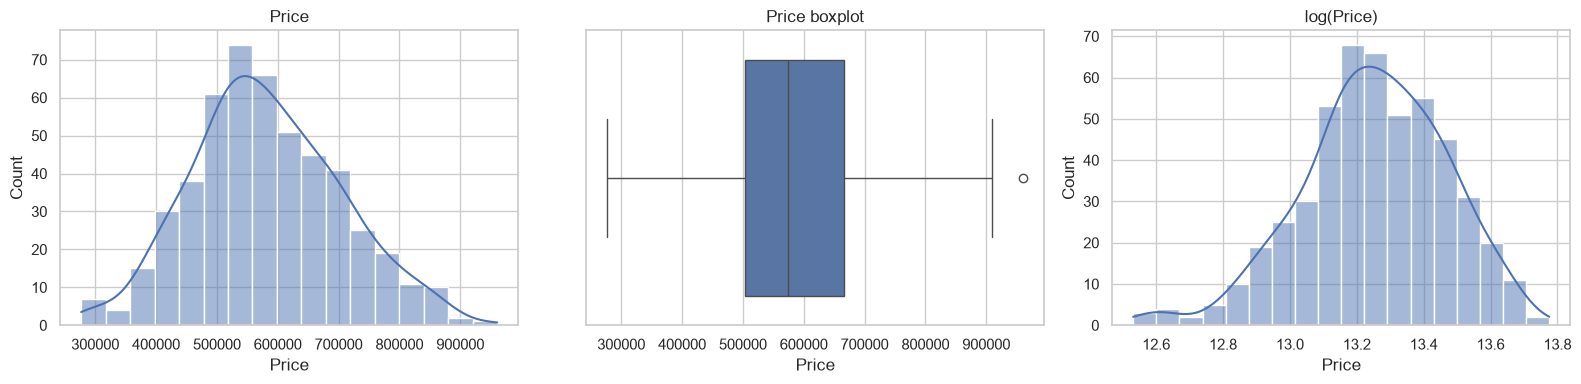

Skewness: 0.21


In [113]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(df_eda['Price'], kde=True, ax=ax[0]); ax[0].set_title('Price')
sns.boxplot(x=df_eda['Price'], ax=ax[1]); ax[1].set_title('Price boxplot')
sns.histplot(np.log1p(df_eda['Price']), kde=True, ax=ax[2]); ax[2].set_title('log(Price)')
plt.tight_layout(); plt.show()
print('Skewness:', round(df_eda['Price'].skew(), 2))

#### 2.2 Numerical Features

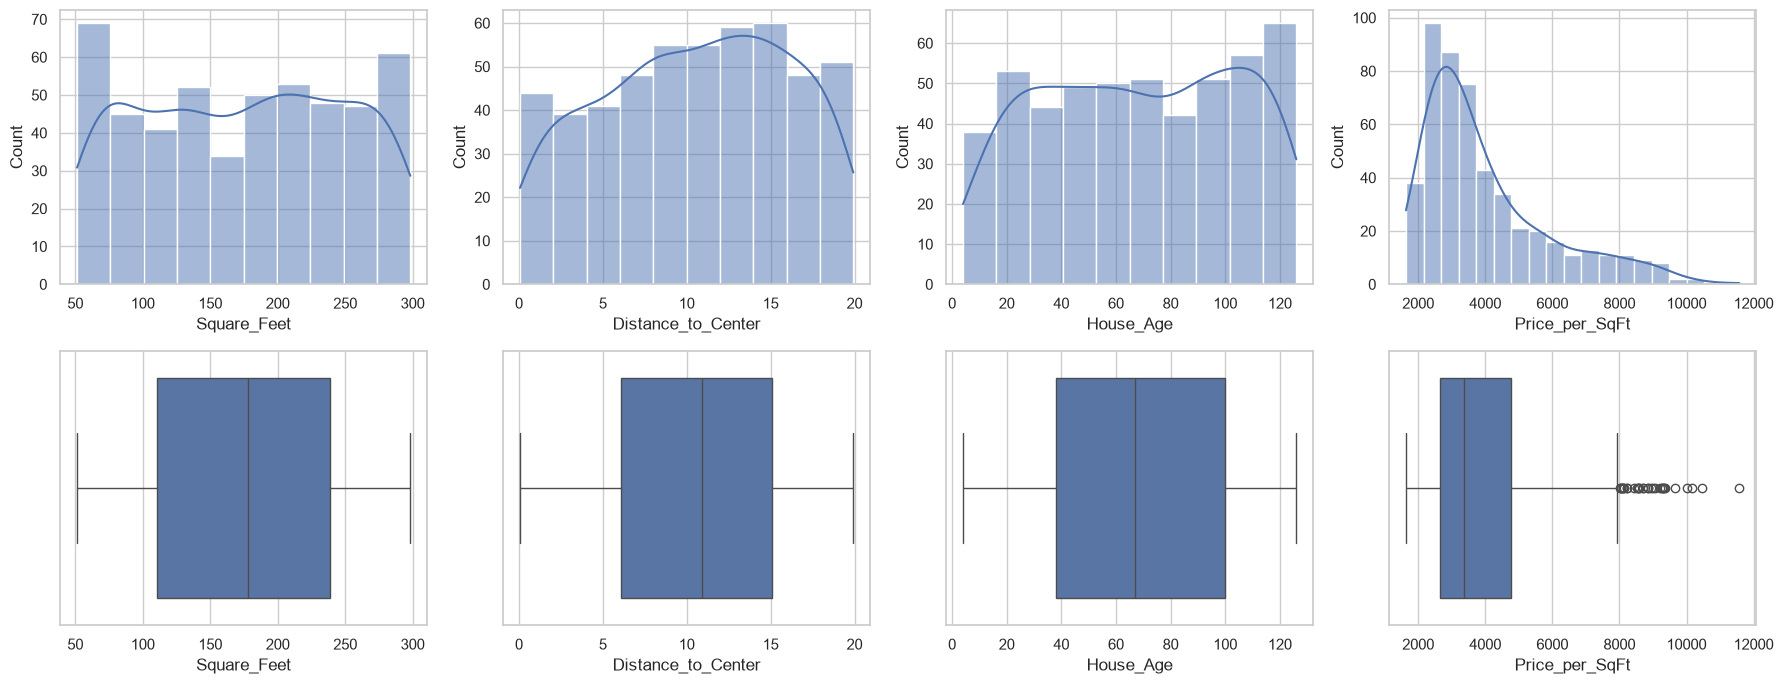

In [114]:
feats = ['Square_Feet','Distance_to_Center','House_Age','Price_per_SqFt']
fig, axes = plt.subplots(2, 4, figsize=(18,7))
for i, c in enumerate(feats):
    sns.histplot(df_eda[c], kde=True, ax=axes[0,i])
    sns.boxplot(x=df_eda[c], ax=axes[1,i])
plt.tight_layout(); plt.show()

#### 2.3 Discrete / categorical features

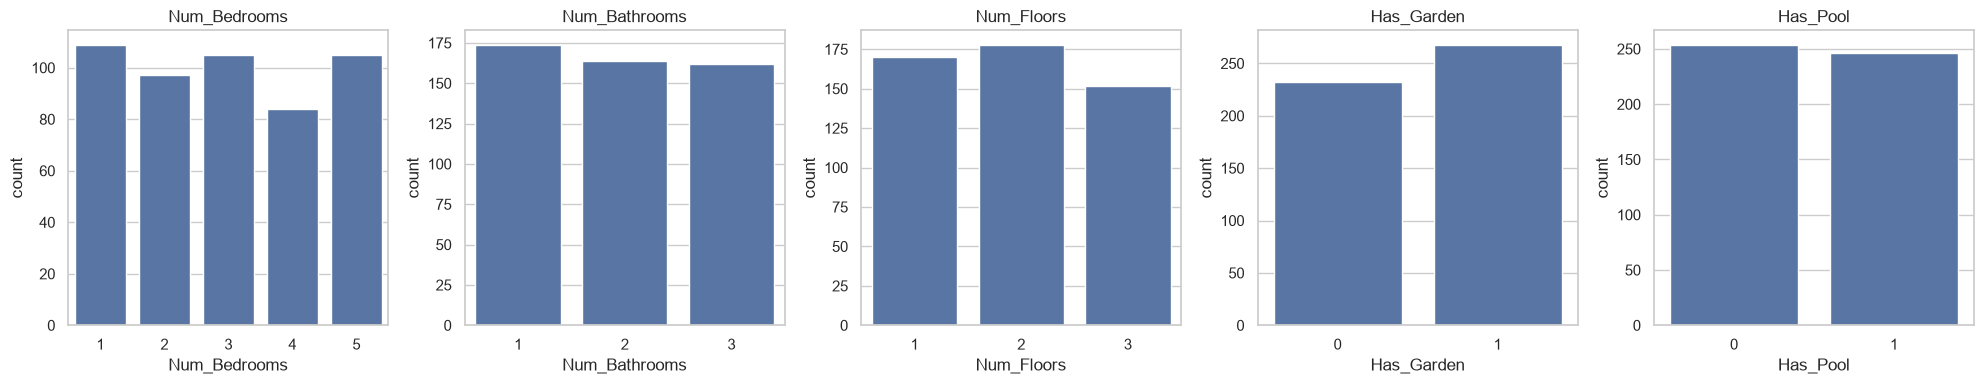

In [115]:
cat_cols = ['Num_Bedrooms','Num_Bathrooms','Num_Floors'] + binary_cols
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, c in zip(axes, cat_cols):
    sns.countplot(x=df_eda[c], ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()

#### 2.4 Garage_Size and Location_Score

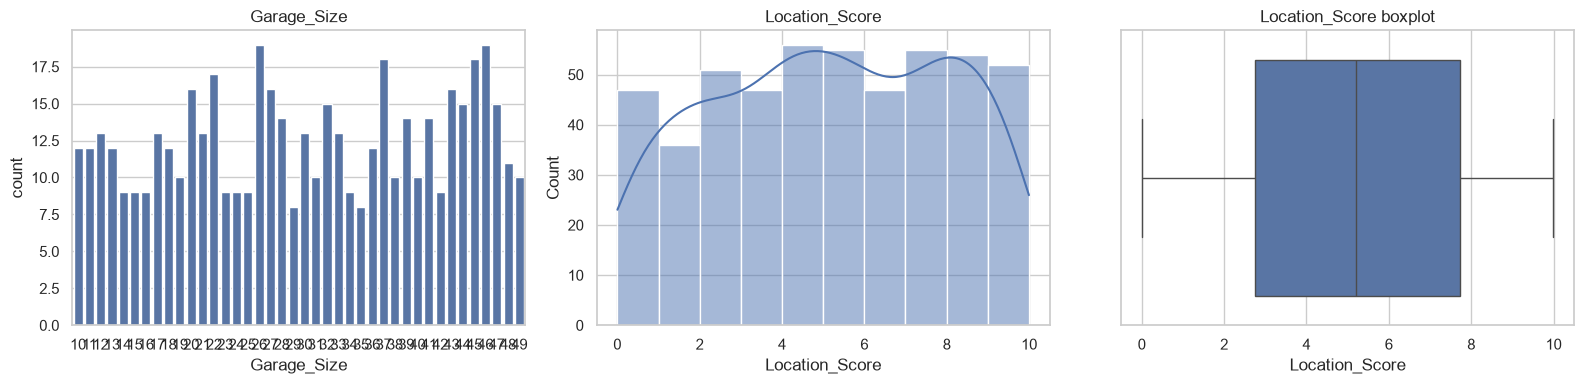

,count,mean,std,min,25%,50%,75%,max
Garage_Size,500.0,30.17400,11.582575,10.000000,20.00000,30.000000,41.000000,49.000000
Location_Score,500.0,5.16441,2.853489,0.004428,2.76065,5.206518,7.732933,9.995439


In [116]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.countplot(x=df_eda['Garage_Size'], ax=axes[0]); axes[0].set_title('Garage_Size')
sns.histplot(df_eda['Location_Score'], kde=True, ax=axes[1]); axes[1].set_title('Location_Score')
sns.boxplot(x=df_eda['Location_Score'], ax=axes[2]); axes[2].set_title('Location_Score boxplot')
plt.tight_layout(); plt.show()
df_eda[['Garage_Size','Location_Score']].describe().T

### 3. Outlier detection (IQR)

In [117]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25,.75]); iqr = q3-q1
    return ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()

out = pd.DataFrame({'Outliers': {c: iqr_outliers(df_eda[c]) for c in ['Price','Square_Feet','Distance_to_Center','House_Age','Price_per_SqFt']}})
out['%'] = (out['Outliers']/len(df_eda)*100).round(2)
out

,Outliers,%
Price,1,0.2
Square_Feet,0,0.0
Distance_to_Center,0,0.0
House_Age,0,0.0
Price_per_SqFt,32,6.4


**Outlier decision:** `Price` has only 1 IQR outlier (0.2%) and the other raw features have none, so **no rows are removed**. `Price_per_SqFt` has 32 (6.4%) but it is derived from the target, so it is excluded from modeling anyway (see 1.1).

### 4. Bivariate analysis: features vs Price

#### 4.1 Numerical vs price

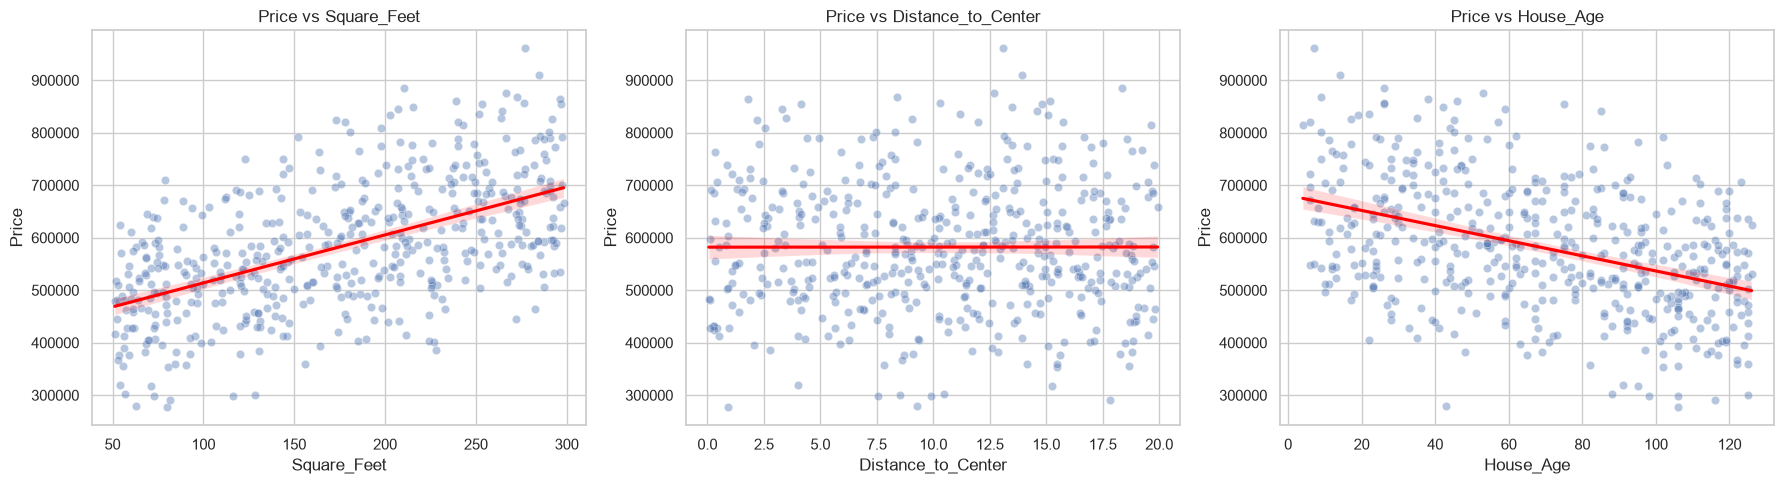

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, c in zip(axes, ['Square_Feet','Distance_to_Center','House_Age']):
    sns.scatterplot(data=df_eda, x=c, y='Price', alpha=.4, ax=ax)
    sns.regplot(data=df_eda, x=c, y='Price', scatter=False, color='red', ax=ax)
    ax.set_title(f'Price vs {c}')
plt.tight_layout(); plt.show()

#### 4.2 Categorical vs Price

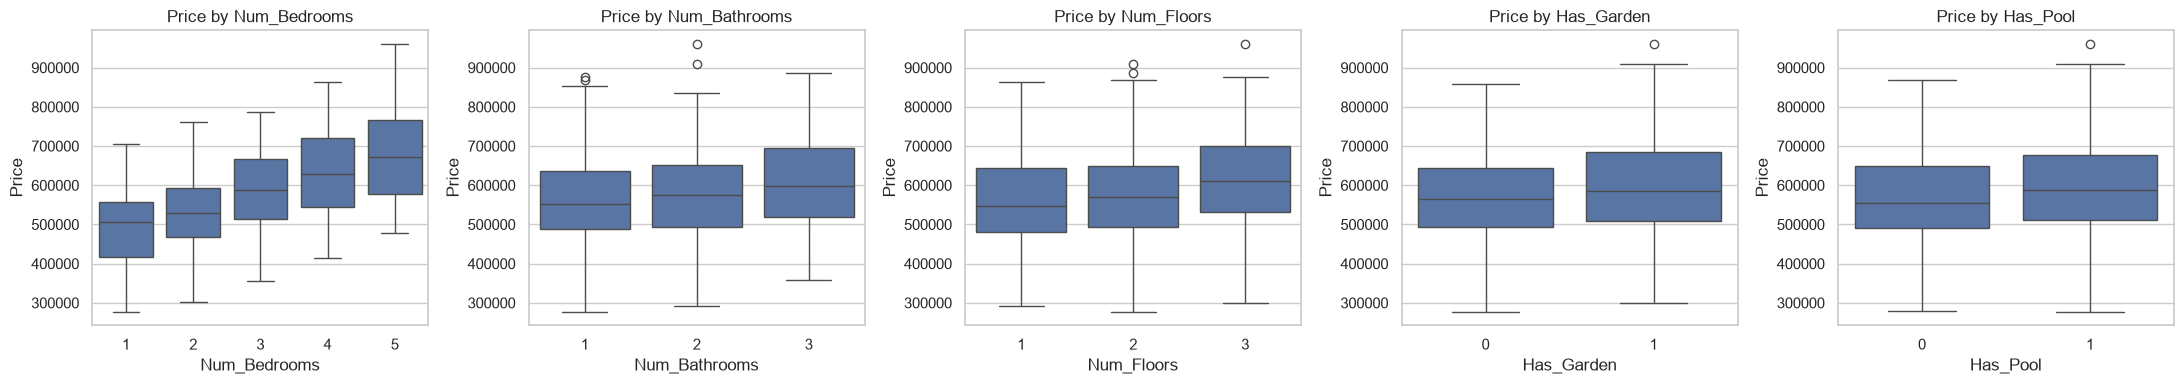

count      mean    median
Has_Garden Has_Pool                           
0          0           107  552810.0  547952.0
           1           125  580768.0  584121.0
1          0           147  575240.0  574653.0
           1           121  618164.0  586944.0

In [119]:
fig, axes = plt.subplots(1, 5, figsize=(22,4))
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=df_eda, x=c, y='Price', ax=ax); ax.set_title(f'Price by {c}')
plt.tight_layout(); plt.show()

df_eda.groupby(binary_cols)['Price'].agg(['count','mean','median']).round(0)

#### 4.3 Location_Score and Garage_Size vs Price

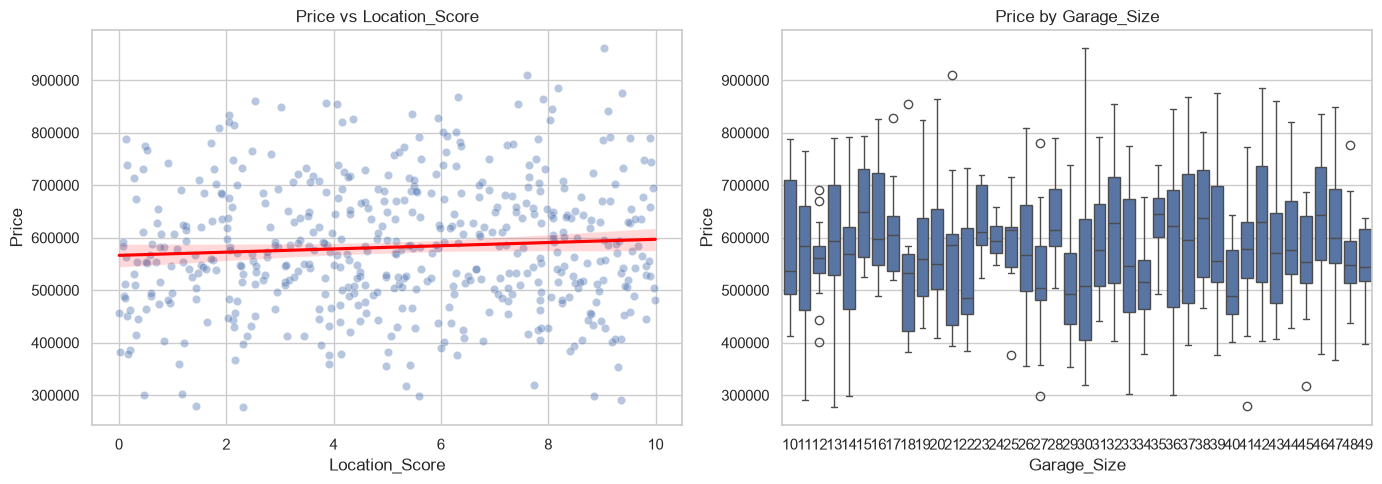

Garage_Size           0.032
Location_Score        0.071
Distance_to_Center    0.001
Price                 1.000
Name: Price, dtype: float64


In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df_eda, x='Location_Score', y='Price', alpha=.4, ax=axes[0])
sns.regplot(data=df_eda, x='Location_Score', y='Price', scatter=False, color='red', ax=axes[0])
axes[0].set_title('Price vs Location_Score')
sns.boxplot(data=df_eda, x='Garage_Size', y='Price', ax=axes[1]); axes[1].set_title('Price by Garage_Size')
plt.tight_layout(); plt.show()
print(df_eda[['Garage_Size','Location_Score','Distance_to_Center','Price']].corr()['Price'].round(3))

### 5. Correlation analysis

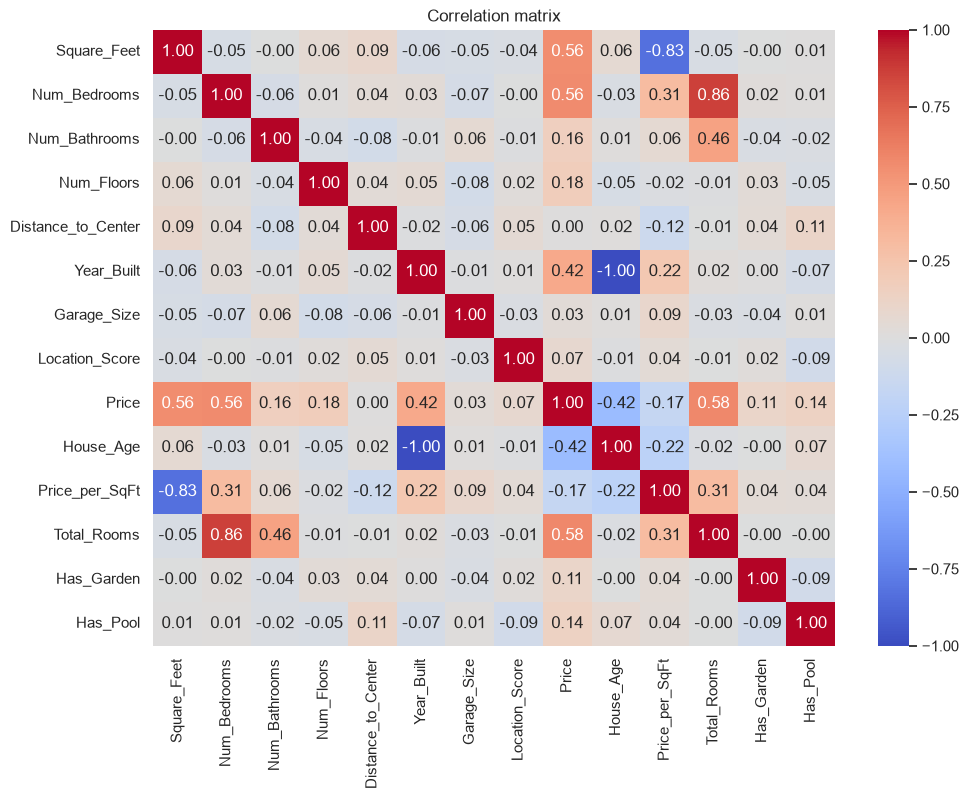

Total_Rooms           0.582037
Num_Bedrooms          0.563973
Square_Feet           0.558604
House_Age            -0.418293
Year_Built            0.418293
Num_Floors            0.177435
Price_per_SqFt       -0.170555
Num_Bathrooms         0.156689
Has_Pool              0.136579
Has_Garden            0.109196
Location_Score        0.071326
Garage_Size           0.032100
Distance_to_Center    0.000730
Name: Price, dtype: float64

In [121]:
corr_cols = num_cols + ['House_Age','Price_per_SqFt','Total_Rooms'] + binary_cols
corr = df_eda[corr_cols].apply(pd.to_numeric, errors='coerce').corr()
plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix'); plt.show()

corr['Price'].drop('Price').sort_values(key=abs, ascending=False)

### 6. Multivariate analysis

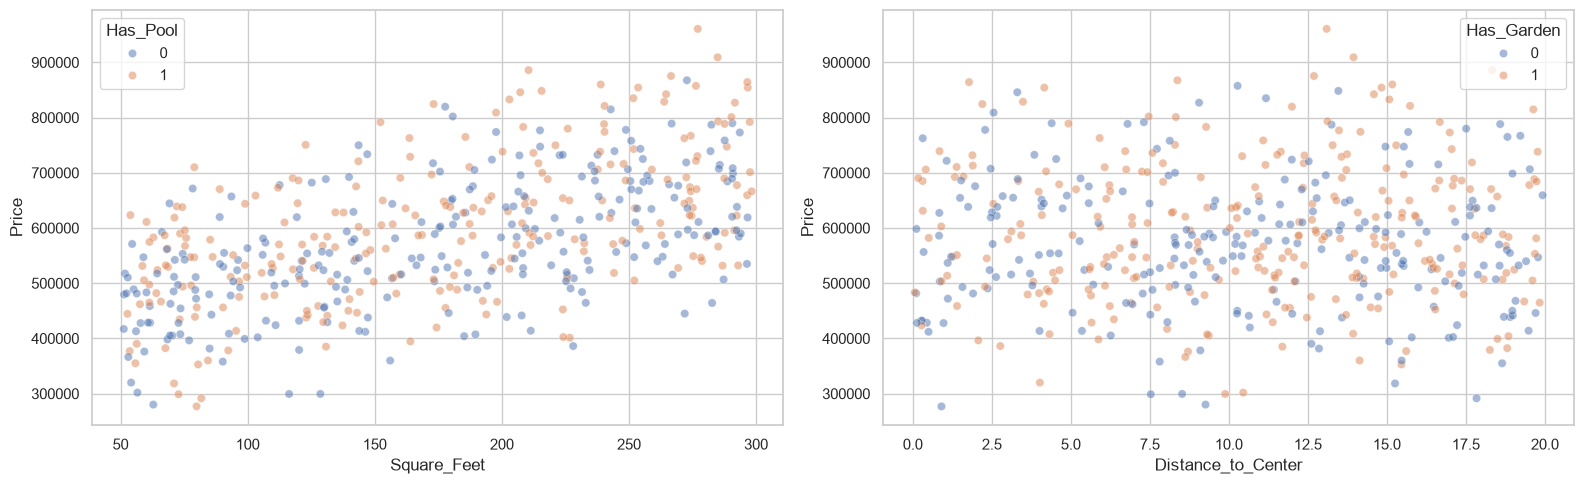

Dist_Group,Close,Medium,Far
Age_Group,,,
0-10,589287.0,720915.0,684180.0
10-25,607281.0,618062.0,569523.0
25-50,666999.0,648176.0,614753.0
50+,544384.0,557100.0,540312.0


In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
sns.scatterplot(data=df_eda, x='Square_Feet', y='Price', hue='Has_Pool', alpha=.5, ax=axes[0])
sns.scatterplot(data=df_eda, x='Distance_to_Center', y='Price', hue='Has_Garden', alpha=.5, ax=axes[1])
plt.tight_layout(); plt.show()

df_eda['Age_Group'] = pd.cut(df_eda['House_Age'], bins=[0,10,25,50,200], labels=['0-10','10-25','25-50','50+'])
df_eda['Dist_Group'] = pd.qcut(df_eda['Distance_to_Center'], 3, labels=['Close','Medium','Far'])
df_eda.pivot_table(values='Price', index='Age_Group', columns='Dist_Group', aggfunc='median', observed=True).round(0)

### EDA conclusions
1. **Price distribution:** roughly symmetric (skew 0.21), so no log-transform is needed.
2. **Strongest relationships with Price:** `Num_Bedrooms` (0.56) and `Square_Feet` (0.56), then `House_Age` (−0.42, newer = pricier). `Num_Floors` and `Num_Bathrooms` are weak (~0.16–0.18).
3. **Garden / Pool:** both add value. Mean price is about 553k with neither, 575k–581k with one, and 618k with both.
4. **Distance to center:** correlation with price is ≈ 0 (0.0007), so on its own it does not drive price here.
5. **House age:** moderate negative correlation; the effect is clear in the correlation but noisy in the age × distance table.
6. **Garage_Size / Location_Score:** *(add your reading of section 4.3 here after running it)*

# **Modeling**
**Goal:** predict `Price` from the house features and find which features matter most.

### 1.1 Select features

In [123]:
drop_cols = ['HouseID', 'Price', 'Price_per_SqFt', 'Year_Built', 'Total_Rooms', 'Age_Group', 'Dist_Group']
X = df_eda.drop(columns=[c for c in drop_cols if c in df_eda.columns])
y = df_eda['Price']
print('Features used:', X.columns.tolist())
print('Shape:', X.shape)

Features used: ['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'House_Age']
Shape: (500, 10)


### 1.2 Train / test split


In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (400, 10) | Test: (100, 10)


### 1.3 Compare models


In [125]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Baseline (mean)':   DummyRegressor(strategy='mean'),
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':             make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows, fitted = [], {}
for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted[name] = model
    rows.append({
        'Model': name,
        'CV R2 (mean)': cv_r2.mean(),
        'CV R2 (std)': cv_r2.std(),
        'Test R2': r2_score(y_test, pred),
        'Test MAE': mean_absolute_error(y_test, pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('CV R2 (mean)', ascending=False)  # select on CV, not on the test set.round(3)
results

,CV R2 (mean),CV R2 (std),Test R2,Test MAE,Test RMSE
Model,,,,,
Ridge,0.973953,0.005346,0.970639,16926.493094,21015.145594
Linear Regression,0.973941,0.005367,0.970899,16850.995605,20922.006589
Gradient Boosting,0.923973,0.010629,0.913958,28951.059546,35975.407538
Random Forest,0.841524,0.025313,0.816856,42774.423275,52486.326471
Baseline (mean),-0.012939,0.011730,-0.056692,101712.078479,126073.757946


### 1.4 Inspect the best model
*(best model = highest cross-validated R², so the test set stays untouched until the final check)*

Best model: Ridge


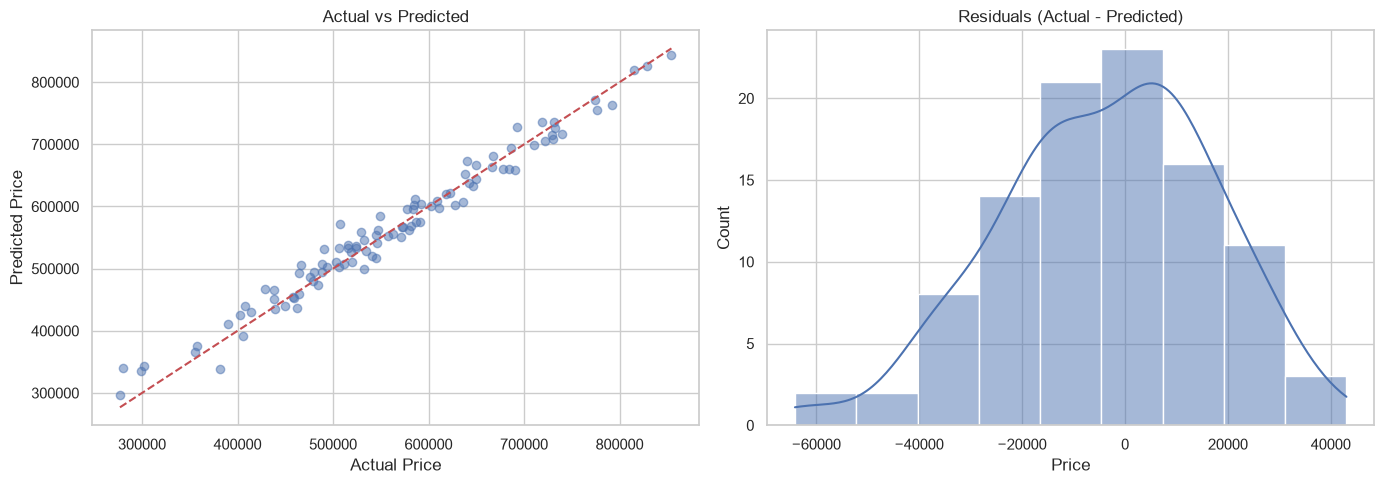

In [126]:
best_name = results.index[0]
best = fitted[best_name]
pred = best.predict(X_test)
print('Best model:', best_name)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, pred, alpha=.5)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('Actual Price'); ax[0].set_ylabel('Predicted Price')
ax[0].set_title('Actual vs Predicted')
sns.histplot(y_test - pred, kde=True, ax=ax[1]); ax[1].set_title('Residuals (Actual - Predicted)')
plt.tight_layout(); plt.show()

#### Residual diagnostics

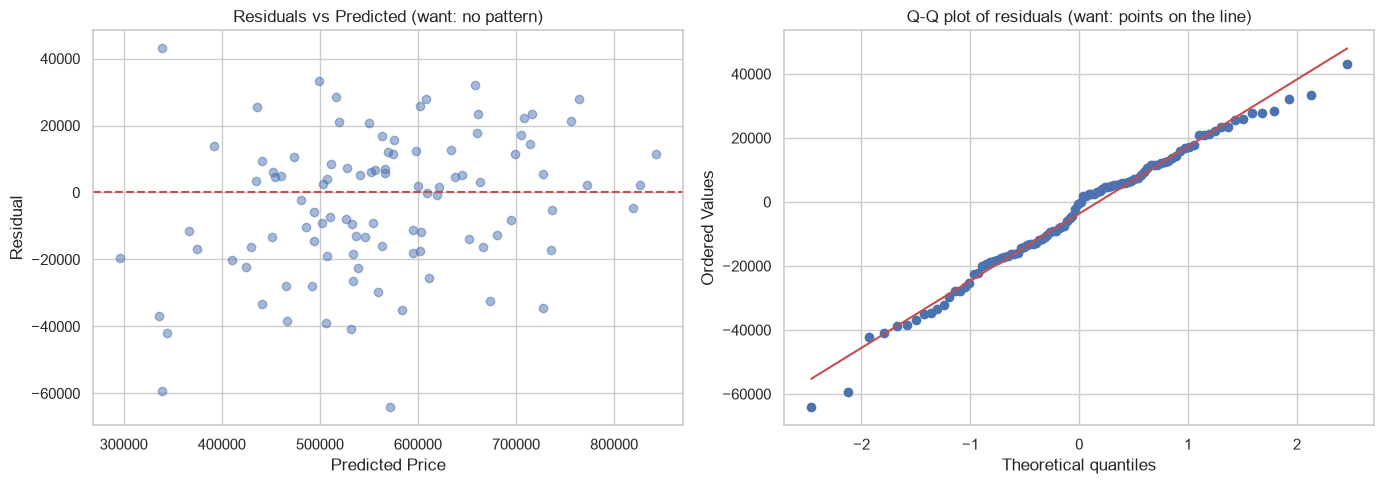

MAPE: 3.41%  ->  predictions are off by about 3.4% on average


In [127]:
from scipy import stats
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].scatter(pred, resid, alpha=.5); ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('Predicted Price'); ax[0].set_ylabel('Residual'); ax[0].set_title('Residuals vs Predicted (want: no pattern)')
stats.probplot(resid, dist='norm', plot=ax[1]); ax[1].set_title('Q-Q plot of residuals (want: points on the line)')
plt.tight_layout(); plt.show()

mape = (np.abs(resid) / y_test).mean() * 100
print(f'MAPE: {mape:.2f}%  ->  predictions are off by about {mape:.1f}% on average')

### 1.5 Which features matter most?


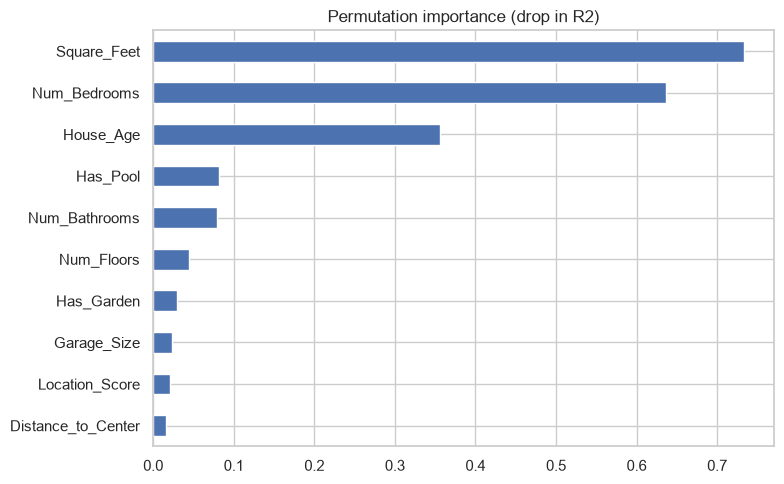

Square_Feet           0.734
Num_Bedrooms          0.636
House_Age             0.357
Has_Pool              0.082
Num_Bathrooms         0.079
Num_Floors            0.044
Has_Garden            0.030
Garage_Size           0.024
Location_Score        0.021
Distance_to_Center    0.016
dtype: float64

In [128]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(best, X_test, y_test, n_repeats=20, random_state=42, scoring='r2')
imp_df = pd.Series(imp.importances_mean, index=X.columns).sort_values()
imp_df.plot(kind='barh', figsize=(8, 5), title='Permutation importance (drop in R2)')
plt.tight_layout(); plt.show()
imp_df.sort_values(ascending=False).round(3)

### 1.6 Coefficients and multicollinearity (linear model)

In [129]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression().fit(X_train, y_train)
coef = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('Intercept:', round(lin.intercept_))
coef.round(1).to_frame('Price change per +1 unit')

Intercept: 183732


,Price change per +1 unit
Num_Bedrooms,50211.1
Has_Pool,46247.8
Num_Bathrooms,30348.3
Has_Garden,30346.4
Num_Floors,19849.7
Location_Score,4788.0
Distance_to_Center,-1883.3
House_Age,-1504.5
Garage_Size,1135.1
Square_Feet,1009.7


In [136]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools import add_constant
    Xc = add_constant(X_train)
    vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                    index=X_train.columns).sort_values(ascending=False).round(2)
    display(vif.to_frame('VIF'))
except ImportError:
    print('statsmodels not installed: run  pip install statsmodels')

,VIF
Has_Pool,1.05
Distance_to_Center,1.05
Num_Floors,1.03
Location_Score,1.02
Num_Bedrooms,1.02
Num_Bathrooms,1.02
Garage_Size,1.02
Square_Feet,1.02
House_Age,1.01
Has_Garden,1.01


### 1.7 Hyperparameter tuning

In [131]:
from sklearn.model_selection import GridSearchCV

searches = {
    'Ridge (tuned)': GridSearchCV(
        make_pipeline(StandardScaler(), Ridge()),
        {'ridge__alpha': np.logspace(-3, 3, 13)}, cv=kf, scoring='r2'),
    'Gradient Boosting (tuned)': GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        {'n_estimators': [100, 300, 500], 'learning_rate': [0.03, 0.1], 'max_depth': [2, 3]},
        cv=kf, scoring='r2', n_jobs=-1),
}
rows = []
for name, gs in searches.items():
    gs.fit(X_train, y_train)
    p = gs.predict(X_test)
    rows.append({'Model': name, 'Best CV R2': gs.best_score_, 'Test R2': r2_score(y_test, p),
                 'Test MAE': mean_absolute_error(y_test, p), 'Best params': gs.best_params_})
tuned = pd.DataFrame(rows).set_index('Model')
tuned.round(3)

,Best CV R2,Test R2,Test MAE,Best params
Model,,,,
Ridge (tuned),0.974,0.971,16926.493,{'ridge__alpha': 1.0}
Gradient Boosting (tuned),0.943,0.937,24103.644,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."


### 1.8 Final model, saving and prediction

In [140]:
from sklearn.base import clone

# pick the tuned model with the best cross-validated score, then retrain on ALL the data
best_search = max(searches.values(), key=lambda g: g.best_score_)
final_model = clone(best_search.best_estimator_).fit(X, y)
joblib.dump({'model': final_model, 'features': X.columns.tolist(), 'ref_year': REF_YEAR}, 'house_price_model.joblib')
print('Saved house_price_model.joblib | final model:', final_model)

Saved house_price_model.joblib | final model: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(1.0)))])


In [133]:
def predict_price(features: dict) -> float:
    """features needs the same columns as X; if you have Year_Built instead of House_Age, pass House_Age = REF_YEAR - Year_Built."""
    row = pd.DataFrame([features])[X.columns.tolist()]
    return float(final_model.predict(row)[0])

# sanity check on a real row
print('Predicted:', round(predict_price(X.iloc[0].to_dict())), '| Actual:', round(y.iloc[0]))

# what-if: a typical house, but bigger and with a pool
typical = X.median().to_dict()
print('Typical house      :', round(predict_price(typical)))
print('Bigger + with pool :', round(predict_price({**typical, 'Square_Feet': 250, 'Has_Pool': 1})))

Predicted: 600463 | Actual: 602135
Typical house      : 581664
Bigger + with pool : 701768


# **Conclusion**
**Result:** a linear model (Ridge / Linear Regression) predicts price best: CV R² ≈ 0.97, test R² ≈ 0.97, MAE ≈ 17k (about X% of the average price). *(update with your final numbers after re-running)*

**Key drivers:** `Square_Feet`, `Num_Bedrooms` and `House_Age`; pool and garden add a smaller premium; distance to center matters little.

**Why linear beats the tree models:** the relationships between features and price are almost linear and the dataset is small (500 rows), so Random Forest / Gradient Boosting have little to gain.

**Limitations:** only 500 houses, likely synthetic data, no real location information beyond one score, and predictions are only valid inside the range of the training data.

**Next steps:** test on real market data, add interaction terms, and wrap `predict_price` in a small web app.